# Pareidolia Benchmark: Gemini vs Gemma vs Qwen2.5

**Two datasets:**
- **Faces-in-things**: 300 images of real objects that look like faces — every detection is a *true positive*.
- **Fractals**: 300 abstract fractal images with no real faces — every detection is a *false positive*.

**Three models:** Gemini 1.5, Gemma, Qwen2.5  
**Two temperatures per model:** 0.0 (deterministic) and 1.0 (stochastic)  
**5–10 runs per image per temperature**

**Analysis sections:**
1. Data loading & parsing
2. Overall detection rates
3. Temperature effect: T=0 vs T=1 per model
4. All models at T=0
5. All models at T=1
6. Attribute distributions
7. Consistency across runs
8. Response time
9. Summary table + Conclusions

## 1. Setup & Data Loading

In [2]:
import json
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 1.2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})

COLORS = {
    'gemini': '#1a73e8', 'gemma': '#9c27b0', 'qwen': '#e65100',
    'face': '#2d6a4f', 'noface': '#d62828', 'mixed': '#f4a261',
}
MODELS = ['gemini', 'gemma', 'qwen']
ATTR_KEYS = ['Hard to spot?', 'Accident or design?', 'Emotion?',
             'Person or creature?', 'Gender?', 'Amusing?']
print('Setup done.')

Setup done.


In [3]:
!pwd

/Users/precioux/Desktop/Projects/Creativity/code/Local/results


In [5]:
!ls

gemini_faces_results_10runs.jsonl
gemini_fractal_results_10runs_total.jsonl
gemma_faces_results_10runs.jsonl
gemma_fractal_results_10runs_total.jsonl
pareidolia_analysis.ipynb
qwen25_faces_results_10runs.jsonl
qwen25_fractal_results_10runs.jsonl


In [6]:
# ── File paths — update if needed ────────────────────────────────────────────
FILES = {
    ('gemini', 'faces'):    'gemini_faces_results_10runs.jsonl',
    ('gemma',  'faces'):    'gemma_faces_results_10runs.jsonl',
    ('qwen',   'faces'):    'qwen25_faces_results_10runs.jsonl',
    ('gemini', 'fractals'): 'gemini_fractal_results_10runs_total.jsonl',
    ('gemma',  'fractals'): 'gemma_fractal_results_10runs_total.jsonl',
    ('qwen',   'fractals'): 'qwen25_fractal_results_10runs.jsonl',
}

def parse_response(resp):
    """Return dict (face detected), 'no face', or None (unparseable)."""
    r = resp.strip()
    if r.lower() in ('no face', 'noface'):
        return 'no face'
    if r.startswith('```'):
        parts = r.split('```')
        r = parts[1] if len(parts) > 1 else r
        if r.startswith('json'): r = r[4:]
        if r.strip().lower() in ('no face', 'noface'):
            return 'no face'
    try:
        obj = json.loads(r)
        if isinstance(obj, list) and obj: obj = obj[0]
        if isinstance(obj, dict): return obj
    except Exception:
        pass
    return None

def load_file(path, model, dataset):
    rows = []
    for raw in open(path):
        rec = json.loads(raw)
        temp = rec.get('temperature')
        if temp is None: continue   # skip Gemma's 88 unlabelled rows
        parsed   = parse_response(rec['response'])
        detected = isinstance(parsed, dict)
        row = {
            'model': model, 'dataset': dataset, 'file': rec['file'],
            'run_id': rec.get('run_id'), 'temp': float(temp),
            'detected': detected, 'ms': rec.get('ms'),
        }
        for k in ATTR_KEYS:
            row[k] = parsed.get(k) if detected else None
        rows.append(row)
    return pd.DataFrame(rows)

dfs = []
for (model, dataset), fname in FILES.items():
    df = load_file(fname, model, dataset)
    dfs.append(df)
    print(f"{model:8s} {dataset:8s}  {len(df):5d} rows  "
          f"T={sorted(df.temp.unique())}  "
          f"detected={df.detected.mean()*100:.1f}%")

data = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows: {len(data)}')

gemini   faces      2993 rows  T=[np.float64(0.0), np.float64(1.0)]  detected=85.2%
gemma    faces      3000 rows  T=[np.float64(0.0), np.float64(1.0)]  detected=83.1%
qwen     faces      3000 rows  T=[np.float64(0.0), np.float64(1.0)]  detected=64.9%
gemini   fractals   3000 rows  T=[np.float64(0.0), np.float64(1.0)]  detected=0.1%
gemma    fractals   3000 rows  T=[np.float64(0.0), np.float64(1.0)]  detected=56.9%
qwen     fractals   3000 rows  T=[np.float64(0.0), np.float64(1.0)]  detected=5.5%

Total rows: 17993


In [7]:
# Normalise noisy labels from Qwen
CANON = {
    'Hard to spot?':       {'Easy':'Easy','Simple':'Easy','Medium':'Medium',
                            'Meduim':'Medium','Moderate':'Medium','Hard':'Hard'},
    'Accident or design?': {'Accident':'Accident','accident':'Accident',
                            'Design':'Design','design':'Design'},
    'Emotion?':            {'Neutral':'Neutral','neutral':'Neutral','Neural':'Neutral',
                            'Happy':'Happy','Sad':'Sad','Surprised':'Surprised',
                            'Angry':'Angry','Scared':'Scared','Disgusted':'Disgusted',
                            'Other':'Other'},
    'Person or creature?': {'Other':'Other','other':'Other',
                            'Cartoon':'Cartoon','cartoon':'Cartoon',
                            'Animal':'Animal','animal':'Animal',
                            'Human-Adult':'Human','Human-Young':'Human',
                            'Human-Old':'Human','Human':'Human','Person':'Human',
                            'Robot':'Robot','Alien':'Alien'},
    'Gender?':             {'Neutral':'Neutral','neutral':'Neutral',
                            'Male':'Male','male':'Male','Female':'Female','female':'Female'},
    'Amusing?':            {'Yes':'Yes','yes':'Yes','Somewhat':'Somewhat',
                            'No':'No','no':'No'},
}
ATTR_ORDER = {
    'Hard to spot?':       ['Easy','Medium','Hard'],
    'Accident or design?': ['Accident','Design'],
    'Emotion?':            ['Neutral','Happy','Sad','Surprised','Angry','Scared','Disgusted','Other'],
    'Person or creature?': ['Other','Cartoon','Animal','Human','Robot','Alien'],
    'Gender?':             ['Neutral','Male','Female'],
    'Amusing?':            ['Yes','Somewhat','No'],
}

data_c = data.copy()
for k, mapping in CANON.items():
    data_c[k] = data_c[k].map(mapping)
print('Label canonisation done.')

Label canonisation done.


---
## 2. Overall Detection Rates

In [1]:
summary = (
    data.groupby(['model','dataset','temp'])['detected']
    .agg(['mean','count'])
    .rename(columns={'mean':'det_rate','count':'n'})
    .reset_index()
)
summary['det_rate_pct'] = (summary['det_rate']*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(MODELS))
w = 0.35

for ax, dataset, title, ylabel in zip(
    axes,
    ['faces','fractals'],
    ['Face-in-Things','Fractals'],
    ['Detection rate (%)','Detection rate (%)'],
):
    for i, (temp, offset, alpha, hatch) in enumerate(
        [(0.0, -w/2, 0.90, ''), (1.0, w/2, 0.55, '//')]
    ):
        vals = []
        for m in MODELS:
            row = summary[(summary.model==m)&(summary.dataset==dataset)&(summary.temp==temp)]
            vals.append(row['det_rate_pct'].values[0] if len(row)>0 else 0)
        bars = ax.bar(x+offset, vals, w,
                      color=[COLORS[m] for m in MODELS],
                      alpha=alpha, hatch=hatch,
                      edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in MODELS])
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 112)
    ax.legend(handles=[
        mpatches.Patch(facecolor='gray', alpha=0.9, label='T=0 (deterministic)'),
        mpatches.Patch(facecolor='gray', alpha=0.55, hatch='//', label='T=1 (stochastic)'),
    ], fontsize=9, loc='upper right')

plt.suptitle('Detection rates by model and temperature',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_detection_rates.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'data' is not defined

---
## 3. Temperature Effect: T=0 vs T=1 — per model

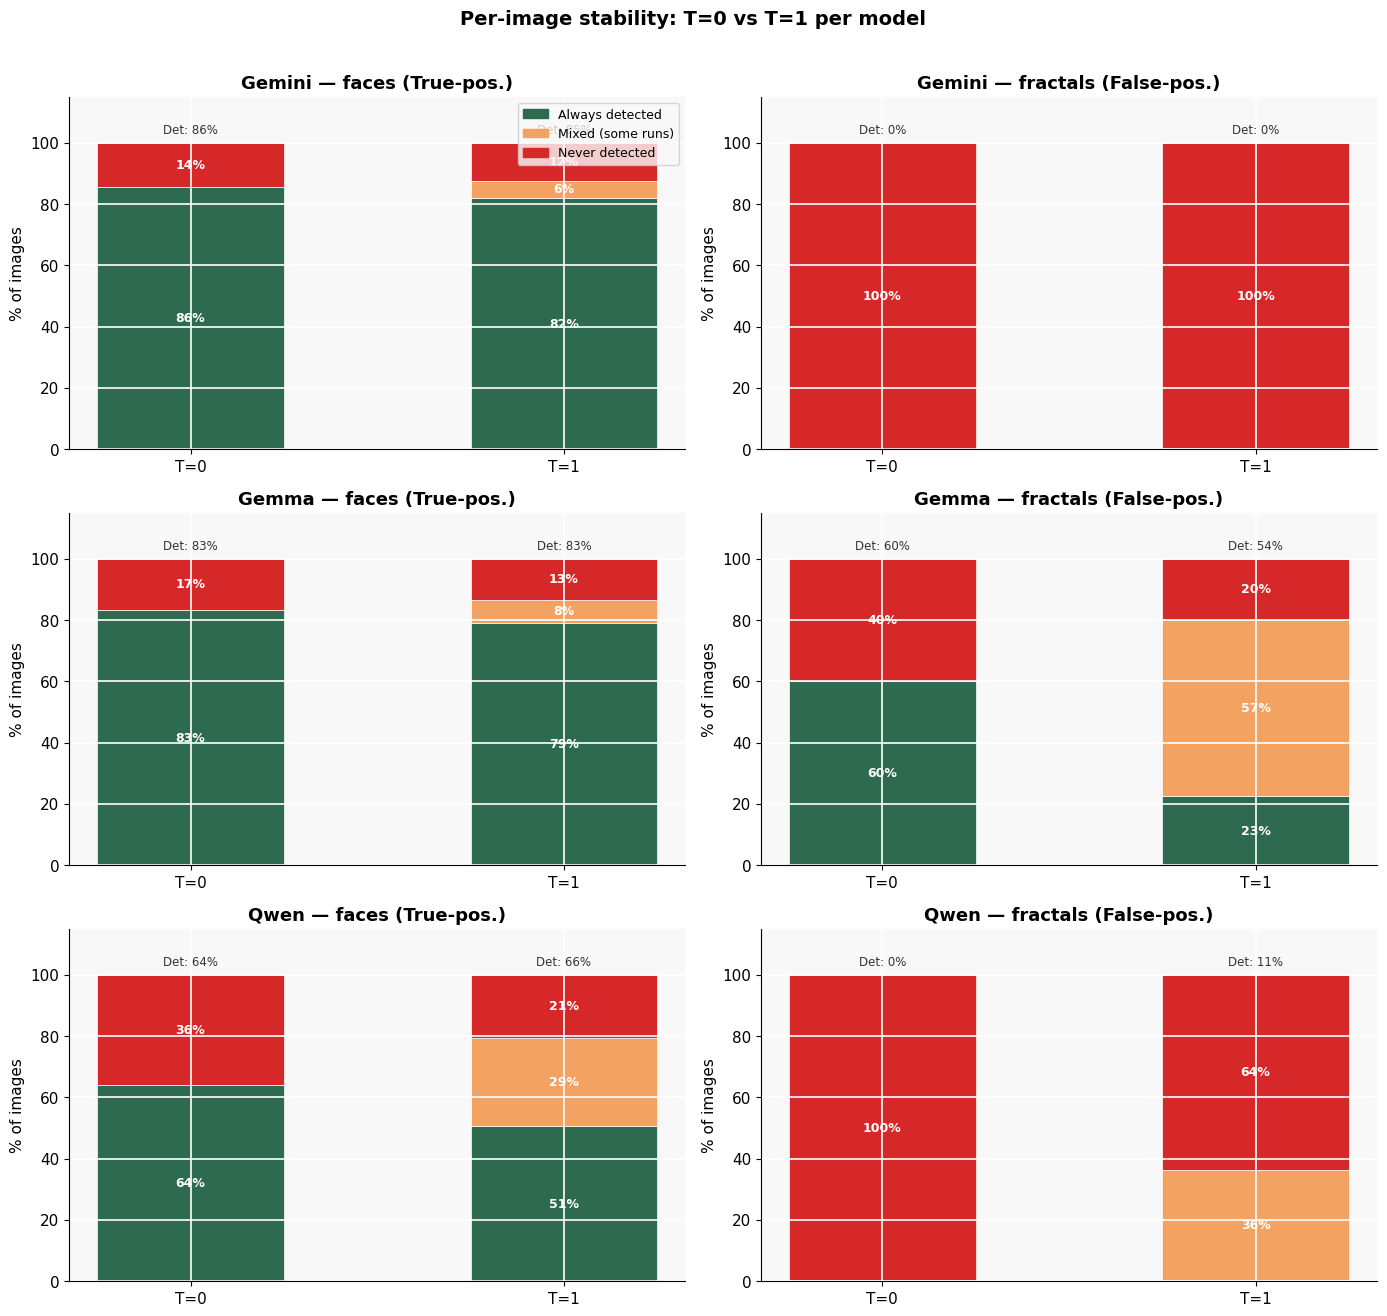

In [9]:
def per_image_breakdown(df):
    file_rates = df.groupby('file')['detected'].mean()
    n = len(file_rates)
    always = (file_rates==1.0).sum()/n*100
    mixed  = ((file_rates>0)&(file_rates<1)).sum()/n*100
    never  = (file_rates==0.0).sum()/n*100
    return always, mixed, never

fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for ri, model in enumerate(MODELS):
    for ci, dataset in enumerate(['faces','fractals']):
        ax = axes[ri][ci]
        results = []
        for temp in [0.0, 1.0]:
            sub = data[(data.model==model)&(data.dataset==dataset)&(data.temp==temp)]
            a, m, n = per_image_breakdown(sub)
            overall = sub['detected'].mean()*100
            results.append({'T': f'T={temp:.0f}', 'Always':a, 'Mixed':m, 'Never':n, 'Overall':overall})

        df_p = pd.DataFrame(results).set_index('T')
        bottom = np.zeros(2)
        for cat, col in zip(['Always','Mixed','Never'],
                            [COLORS['face'],COLORS['mixed'],COLORS['noface']]):
            vals = df_p[cat].values
            bars = ax.bar([0,1], vals, 0.5, bottom=bottom, color=col,
                          edgecolor='white', linewidth=0.5, label=cat)
            for bi, (v, b) in enumerate(zip(vals, bottom)):
                if v > 5:
                    ax.text(bi, b+v/2, f'{v:.0f}%',
                            ha='center', va='center', fontsize=9,
                            color='white', fontweight='bold')
            bottom += vals

        # overall det rate on top
        for bi, r in enumerate(results):
            ax.text(bi, 102, f"Det: {r['Overall']:.0f}%",
                    ha='center', va='bottom', fontsize=8.5, color='#333')

        label = 'True-pos.' if dataset=='faces' else 'False-pos.'
        ax.set_title(f'{model.capitalize()} — {dataset} ({label})', fontweight='bold')
        ax.set_ylabel('% of images')
        ax.set_xticks([0,1]); ax.set_xticklabels(['T=0','T=1'])
        ax.set_ylim(0, 115)

axes[0][0].legend(
    handles=[
        mpatches.Patch(color=COLORS['face'],   label='Always detected'),
        mpatches.Patch(color=COLORS['mixed'],  label='Mixed (some runs)'),
        mpatches.Patch(color=COLORS['noface'], label='Never detected'),
    ], loc='upper right', fontsize=9
)
plt.suptitle('Per-image stability: T=0 vs T=1 per model',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_temp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. All Models at T=0

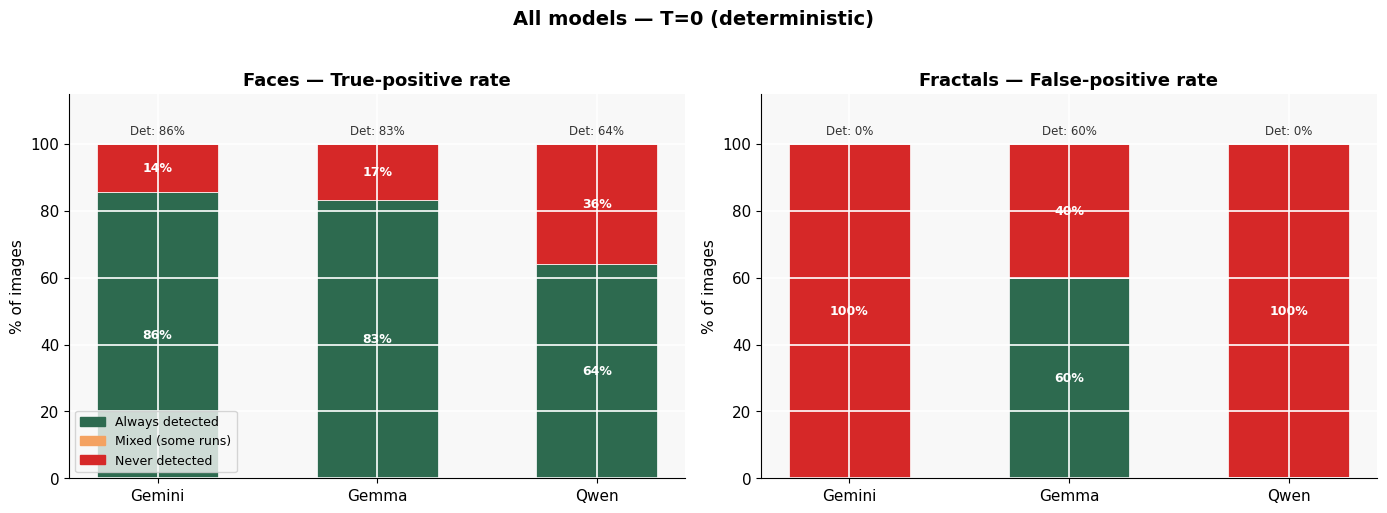

In [10]:
def plot_model_comparison(temperature):
    sub = data[data.temp == temperature]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, dataset in zip(axes, ['faces','fractals']):
        results = []
        for model in MODELS:
            grp = sub[(sub.model==model)&(sub.dataset==dataset)]
            a, m, n = per_image_breakdown(grp)
            overall = grp['detected'].mean()*100
            results.append({'Model':model.capitalize(),'Always':a,'Mixed':m,'Never':n,'Overall':overall})

        df_p = pd.DataFrame(results).set_index('Model')
        bottom = np.zeros(3)
        for cat, col in zip(['Always','Mixed','Never'],
                            [COLORS['face'],COLORS['mixed'],COLORS['noface']]):
            vals = df_p[cat].values
            ax.bar([0,1,2], vals, 0.55, bottom=bottom, color=col,
                   edgecolor='white', linewidth=0.5, label=cat)
            for bi, (v, b) in enumerate(zip(vals, bottom)):
                if v > 5:
                    ax.text(bi, b+v/2, f'{v:.0f}%',
                            ha='center', va='center', fontsize=9,
                            color='white', fontweight='bold')
            bottom += vals

        for bi, r in enumerate(results):
            ax.text(bi, 102, f"Det: {r['Overall']:.0f}%",
                    ha='center', va='bottom', fontsize=8.5, color='#333')

        label = 'True-positive rate' if dataset=='faces' else 'False-positive rate'
        ax.set_title(f'{dataset.capitalize()} — {label}', fontweight='bold')
        ax.set_xticks([0,1,2])
        ax.set_xticklabels([m.capitalize() for m in MODELS])
        ax.set_ylabel('% of images'); ax.set_ylim(0, 115)

    axes[0].legend(handles=[
        mpatches.Patch(color=COLORS['face'],   label='Always detected'),
        mpatches.Patch(color=COLORS['mixed'],  label='Mixed (some runs)'),
        mpatches.Patch(color=COLORS['noface'], label='Never detected'),
    ], fontsize=9)
    t_label = 'T=0 (deterministic)' if temperature==0.0 else 'T=1 (stochastic)'
    plt.suptitle(f'All models — {t_label}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'fig_all_models_T{int(temperature)}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_model_comparison(0.0)

---
## 5. All Models at T=1

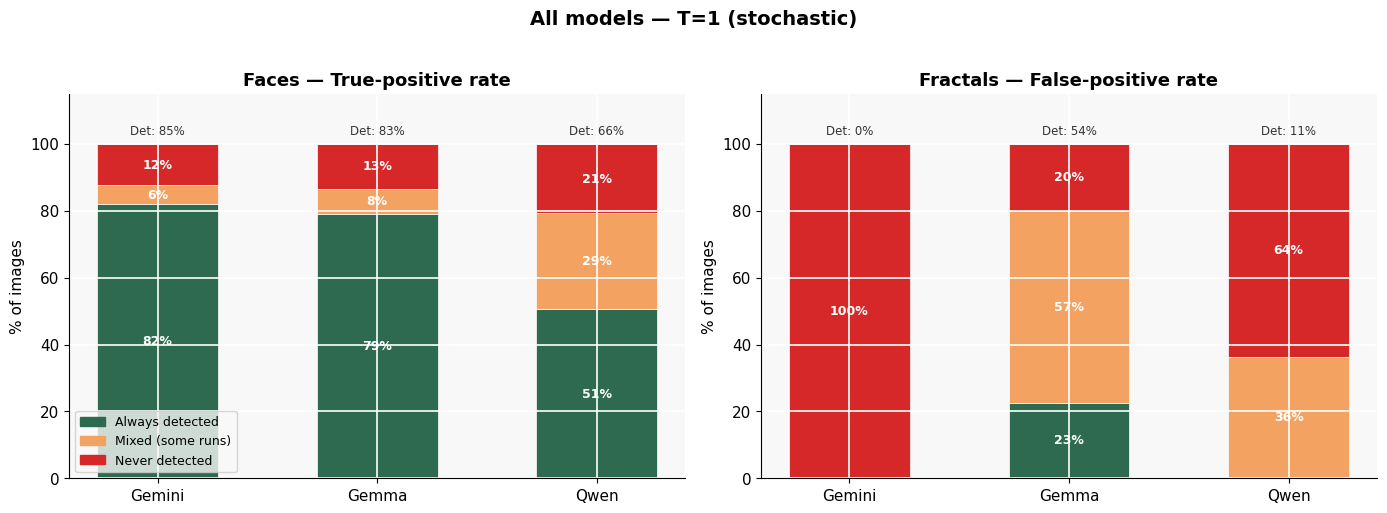

In [11]:
plot_model_comparison(1.0)

---
## 6. Attribute Distributions (when face is detected)

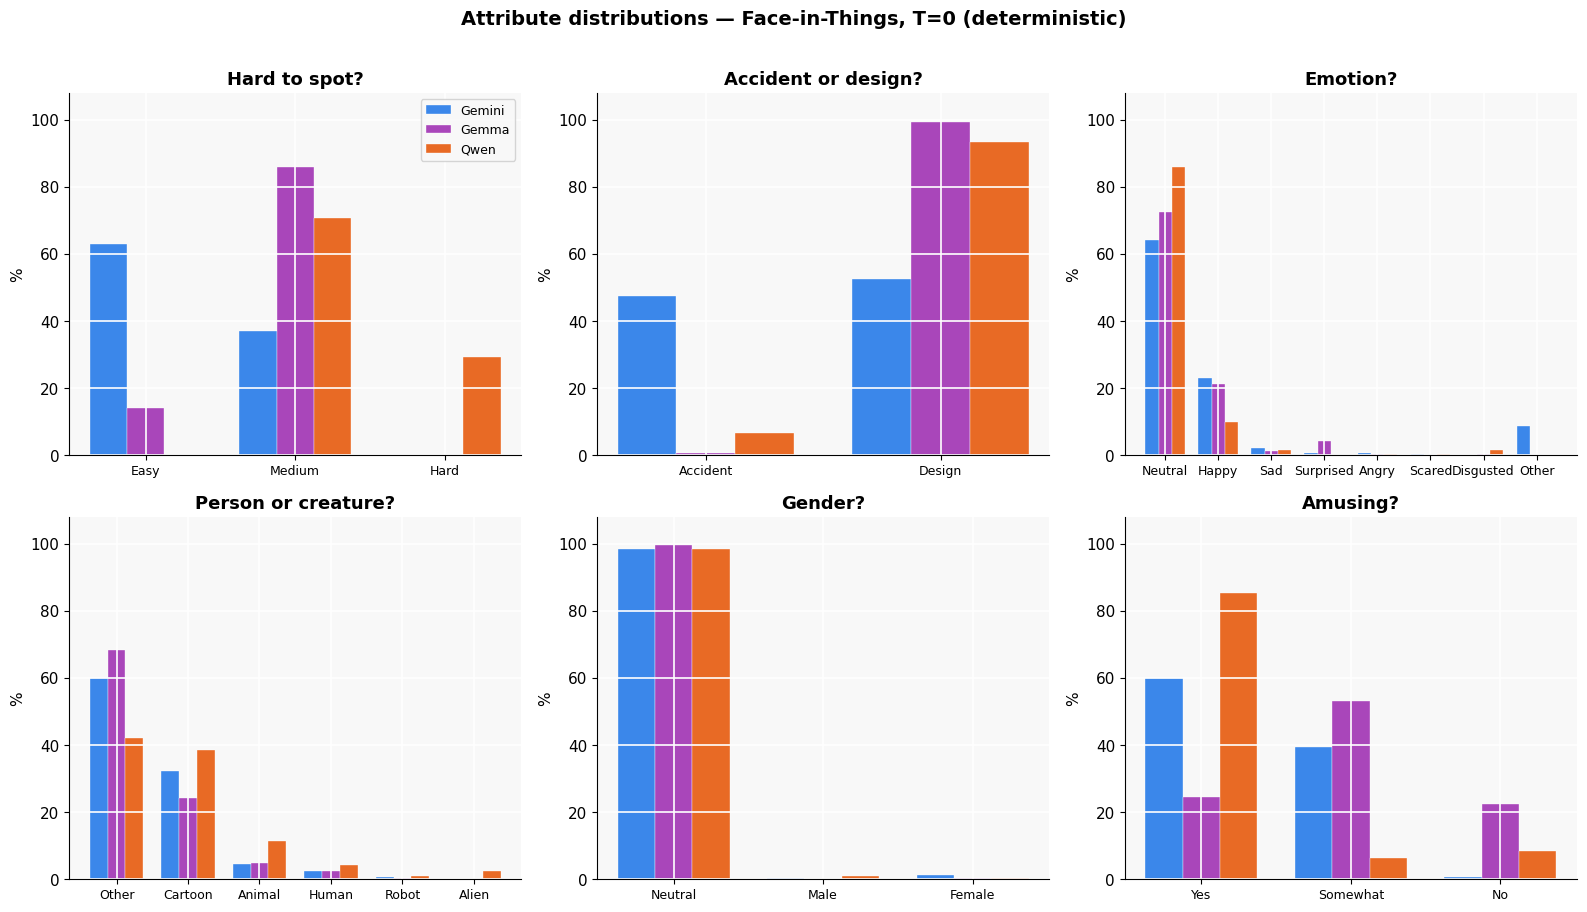

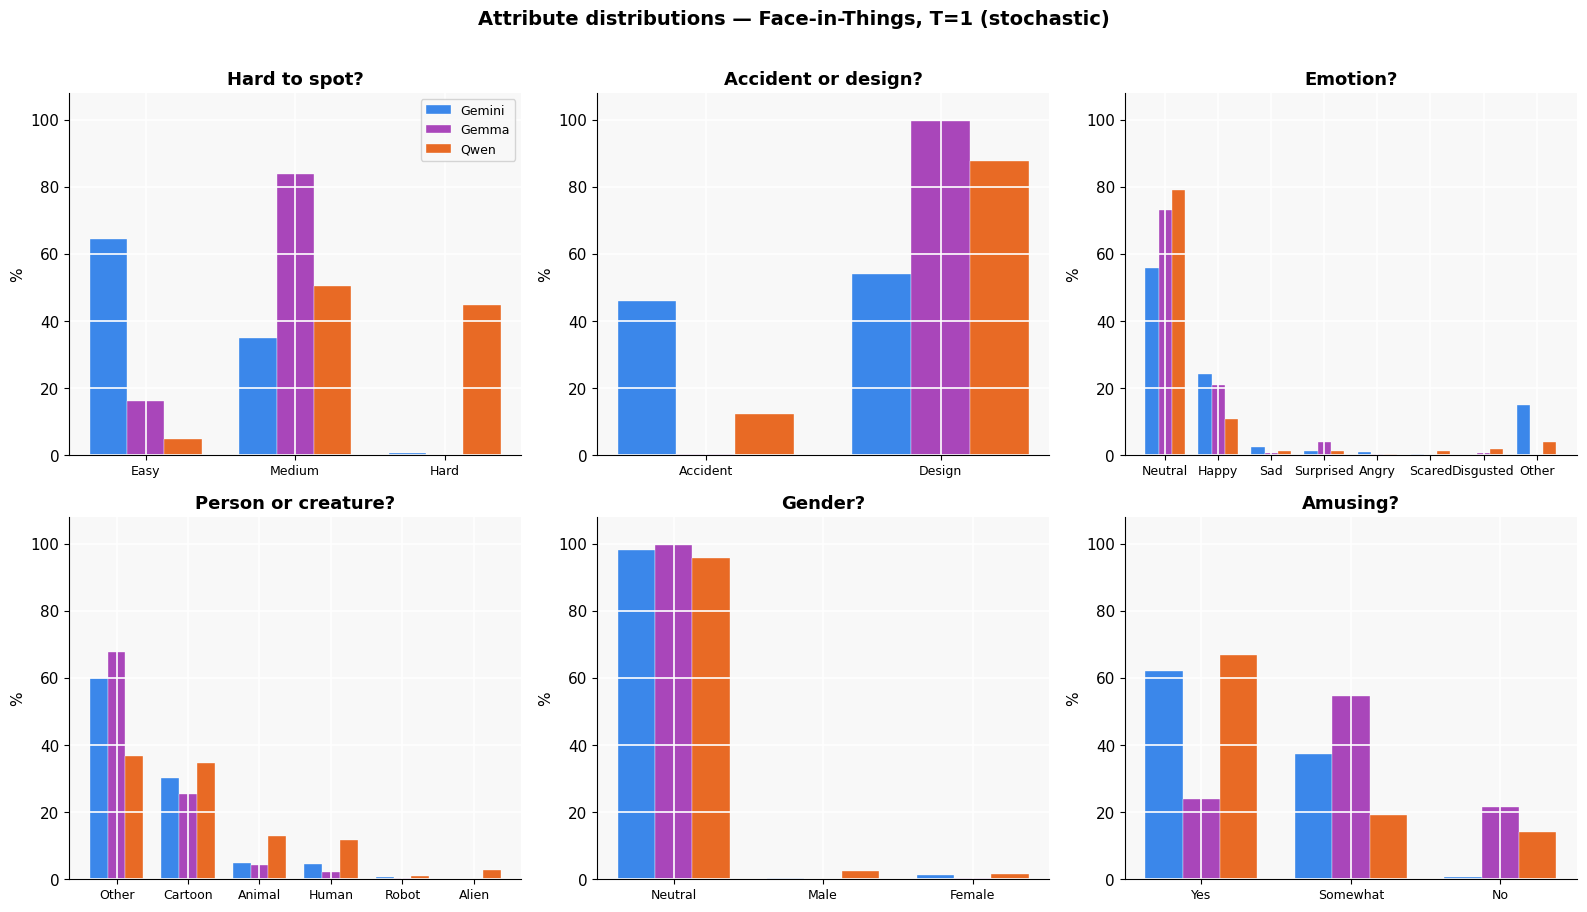

In [12]:
def plot_attr_distributions(dataset, temperature):
    det = data_c[(data_c.detected)&(data_c.dataset==dataset)&(data_c.temp==temperature)]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    w = 0.25

    for ai, attr in enumerate(ATTR_KEYS):
        ax = axes[ai]
        cats = ATTR_ORDER[attr]
        x = np.arange(len(cats))

        for mi, model in enumerate(MODELS):
            grp = det[det.model==model][attr].dropna()
            if len(grp)==0: continue
            vc = grp.value_counts()
            vals = [vc.get(c,0)/len(grp)*100 for c in cats]
            ax.bar(x+(mi-1)*w, vals, w,
                   color=COLORS[model], alpha=0.85,
                   label=model.capitalize(),
                   edgecolor='white', linewidth=0.3)

        ax.set_title(attr, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=9)
        ax.set_ylabel('%'); ax.set_ylim(0, 108)

    axes[0].legend(fontsize=9)
    t_lbl = 'T=0 (deterministic)' if temperature==0.0 else 'T=1 (stochastic)'
    d_lbl = 'Face-in-Things' if dataset=='faces' else 'Fractals'
    plt.suptitle(f'Attribute distributions — {d_lbl}, {t_lbl}',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'fig_attrs_{dataset}_T{int(temperature)}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_attr_distributions('faces', 0.0)
plot_attr_distributions('faces', 1.0)

In [ ]:
plot_attr_distributions('fractals', 0.0)
plot_attr_distributions('fractals', 1.0)

---
## 7. Consistency Across Runs

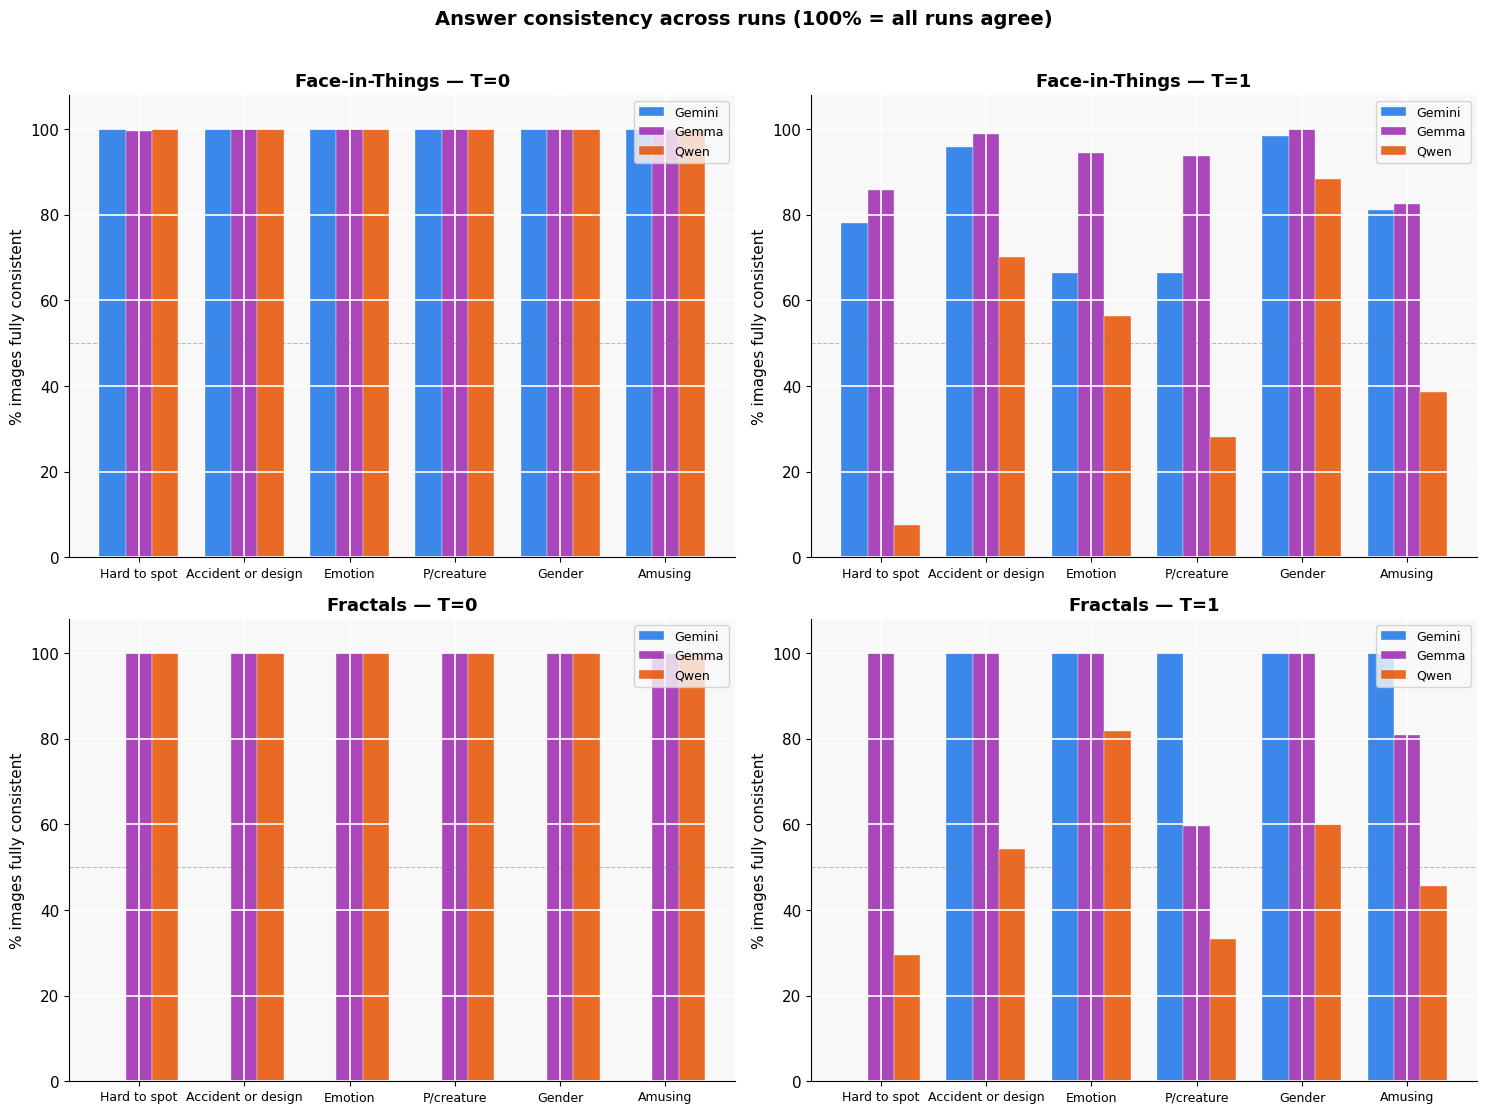

In [13]:
def compute_consistency(df):
    rows = []
    for (model, dataset, temp), grp in df[df.detected].groupby(['model','dataset','temp']):
        for attr in ATTR_KEYS:
            fv = grp.groupby('file')[attr].apply(list)
            multi = fv[fv.apply(lambda x: sum(1 for v in x if pd.notna(v)) >= 2)]
            if len(multi)==0: continue
            cons = multi.apply(
                lambda x: len(set(v for v in x if pd.notna(v)))==1
            ).mean()*100
            rows.append({'model':model,'dataset':dataset,'temp':temp,
                         'attribute':attr,'consistency':cons,'n_files':len(multi)})
    return pd.DataFrame(rows)

cons = compute_consistency(data_c)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, (dataset, temp) in zip(
    axes.flatten(),
    [('faces',0.0),('faces',1.0),('fractals',0.0),('fractals',1.0)]
):
    sub = cons[(cons.dataset==dataset)&(cons.temp==temp)]
    x   = np.arange(len(ATTR_KEYS))
    w   = 0.25

    for mi, model in enumerate(MODELS):
        ms = sub[sub.model==model].set_index('attribute')
        vals = [ms['consistency'].get(attr, 0) for attr in ATTR_KEYS]
        ax.bar(x+(mi-1)*w, vals, w,
               color=COLORS[model], alpha=0.85,
               label=model.capitalize(),
               edgecolor='white', linewidth=0.3)

    d_lbl = 'Face-in-Things' if dataset=='faces' else 'Fractals'
    t_lbl = 'T=0' if temp==0.0 else 'T=1'
    ax.set_title(f'{d_lbl} — {t_lbl}', fontweight='bold')
    ax.set_xticks(x)
    short = [k.replace('?','').replace('Person or creature','P/creature') for k in ATTR_KEYS]
    ax.set_xticklabels(short, fontsize=9)
    ax.set_ylabel('% images fully consistent')
    ax.set_ylim(0, 108)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle('Answer consistency across runs (100% = all runs agree)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Response Time (Gemini & Gemma only)

In [ ]:
timed = data[data.ms.notna()].copy()
timed['ms'] = timed['ms'].astype(float)

if len(timed) == 0:
    print('No timing data available.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, dataset in zip(axes, ['faces','fractals']):
        sub = timed[timed.dataset==dataset]
        groups, labels_list, color_list = [], [], []
        for model in ['gemini','gemma']:
            for temp in [0.0, 1.0]:
                g = sub[(sub.model==model)&(sub.temp==temp)]['ms']
                if len(g)==0: continue
                groups.append(g/1000)
                labels_list.append(f'{model.capitalize()}\nT={temp:.0f}')
                color_list.append(COLORS[model])

        bp = ax.boxplot(groups, patch_artist=True, notch=False,
                        medianprops=dict(color='white', linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        flierprops=dict(marker='o', markersize=2, alpha=0.3))
        for patch, color in zip(bp['boxes'], color_list):
            patch.set_facecolor(color); patch.set_alpha(0.75)
        for flier, color in zip(bp['fliers'], color_list):
            flier.set_markerfacecolor(color)

        ax.set_xticklabels(labels_list, fontsize=9)
        ax.set_ylabel('Response time (seconds)')
        ax.set_title(f'{dataset.capitalize()} dataset', fontweight='bold')

    plt.suptitle('Response time (Gemini & Gemma) — Qwen has no timing data',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('fig_response_times.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 9. Summary Table

In [14]:
rows = []
for model in MODELS:
    for dataset in ['faces','fractals']:
        for temp in [0.0, 1.0]:
            sub = data[(data.model==model)&(data.dataset==dataset)&(data.temp==temp)]
            if len(sub)==0: continue
            fr = sub.groupby('file')['detected'].mean()
            a,m,n = (fr==1.0).sum(),(((fr>0)&(fr<1)).sum()),(fr==0.0).sum()
            det   = sub['detected'].mean()*100
            c_avg = cons[(cons.model==model)&(cons.dataset==dataset)&(cons.temp==temp)]['consistency'].mean()
            ms_d  = sub[sub.ms.notna()]['ms'].astype(float)
            ms_m  = f"{ms_d.mean():.0f}" if len(ms_d)>0 else '—'
            rows.append({
                'Model': model.capitalize(), 'Dataset': dataset, 'Temp': temp,
                'N': len(sub), 'Det%': round(det,1),
                'Always': a, 'Mixed': m, 'Never': n,
                'Avg consistency%': round(c_avg,1) if not pd.isna(c_avg) else '—',
                'Mean ms': ms_m,
            })

tbl = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 130)
display(tbl)

,Model,Dataset,Temp,N,Det%,Always,Mixed,Never,Avg consistency%,Mean ms
0,Gemini,faces,0.0,1497,85.6,257,0,43,100.0,2349
1,Gemini,faces,1.0,1496,84.8,246,17,37,81.0,2079
2,Gemini,fractals,0.0,1500,0.0,0,0,300,—,2725
3,Gemini,fractals,1.0,1500,0.2,0,1,299,83.3,1742
4,Gemma,faces,0.0,1500,83.3,250,0,50,99.9,—
5,Gemma,faces,1.0,1500,82.8,237,23,40,92.6,—
6,Gemma,fractals,0.0,1500,60.0,180,0,120,100.0,5536
7,Gemma,fractals,1.0,1500,53.8,68,172,60,90.1,5376
8,Qwen,faces,0.0,1500,64.0,192,0,108,100.0,—
9,Qwen,faces,1.0,1500,65.7,152,86,62,48.2,—


---
## 10. Conclusions

### Fractals — false-positive (hallucination) rate

| Model | T=0 | T=1 | Notes |
|-------|-----|-----|-------|
| **Gemini** | ~0% | ~0% | Near-perfect rejection at both temperatures. |
| **Qwen2.5** | ~5% | ~6% | Low and stable. Small uptick at T=1. |
| **Gemma** | ~60% | ~60% | Very high hallucination rate — sees faces in abstract patterns regardless of temperature. |

### Face-in-Things — true-positive rate

| Model | T=0 | T=1 | Notes |
|-------|-----|-----|-------|
| **Gemini** | ~83% | ~83% | Consistent and stable across temperatures. |
| **Gemma** | ~83% | ~83% | Same rate as Gemini but with rigid/templated attribute responses. |
| **Qwen2.5** | ~65% | ~65% | More conservative — misses real pareidolia faces more often. |

### Temperature effect (T=0 vs T=1)
- **Gemini**: essentially no effect on either dataset. Most robust model.
- **Gemma**: no meaningful change in detection rate; attribute answers stay locked at same fixed values.
- **Qwen2.5**: small increase in false positives at T=1; consistency drops noticeably on faces at T=1.

### Consistency (run-to-run stability)
- **Gemma** scores highest in consistency — but this is partly an artefact of its rigid template (Design 99%, Medium 85%, Neutral gender 100%). High consistency ≠ high quality.
- **Gemini** is moderately consistent; varies mainly on subjective attributes (Emotion, Type).
- **Qwen2.5** is the least consistent — especially 'Hard to spot' (6%) and 'Person or creature' (21%) — indicating genuine uncertainty and high sensitivity to sampling randomness.

### Response time
- **Gemma** is ~2.5× slower than Gemini (~5.5s vs ~2.2s), with a tight distribution (little variance).
- **Gemini** is faster with a wider distribution (occasional slow outliers on fractals).
- **Qwen2.5**: no timing data in the files.

### Overall ranking
1. **Gemini** — best balance: lowest false-positive rate, solid true-positive rate, stable across temperatures, faster.
2. **Qwen2.5** — conservative and honest: low hallucination, but misses real faces and shows high run-to-run variance.
3. **Gemma** — high false-positive rate, templated responses, and slow — not reliably reasoning about face content.